# CREAM Multi-Seed Analysis — AWA2 & CUB
- Section 1: Setup & data loading
- Section 2: Task & concept accuracy (mean ± std across seeds)
- Section 3: Intervention curves (mean ± std across seeds)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

EXPERIMENTS_ROOT = Path('/home/dani00003/mCREAM/experiments')

DATASETS = {
    'AWA2': {
        'model':   'Standard_AWA2_resnet101',
        'exp':     'CREAM_awa2',
        'seeds':   [0, 1, 2],
        'color':   '#2980b9',
    },
    'CUB': {
        'model':   'Standard_CUB',
        'exp':     'CREAM_cub',
        'seeds':   [0, 1, 2, 3, 4],
        'color':   '#27ae60',
    },
}

def seed_dir(dataset, seed):
    cfg = DATASETS[dataset]
    return (EXPERIMENTS_ROOT / dataset / 'train_cbm' / cfg['model']
            / 'CREAM' / cfg['exp'] / f'seed_{seed}')

# Verify paths
for ds, cfg in DATASETS.items():
    for s in cfg['seeds']:
        p = seed_dir(ds, s)
        print(f'{ds} seed_{s}: {"OK" if p.exists() else "NOT FOUND"} — {p.relative_to(EXPERIMENTS_ROOT)}')

AWA2 seed_0: OK — AWA2/train_cbm/Standard_AWA2_resnet101/CREAM/CREAM_awa2/seed_0
AWA2 seed_1: OK — AWA2/train_cbm/Standard_AWA2_resnet101/CREAM/CREAM_awa2/seed_1
AWA2 seed_2: OK — AWA2/train_cbm/Standard_AWA2_resnet101/CREAM/CREAM_awa2/seed_2
CUB seed_0: OK — CUB/train_cbm/Standard_CUB/CREAM/CREAM_cub/seed_0
CUB seed_1: OK — CUB/train_cbm/Standard_CUB/CREAM/CREAM_cub/seed_1
CUB seed_2: OK — CUB/train_cbm/Standard_CUB/CREAM/CREAM_cub/seed_2
CUB seed_3: OK — CUB/train_cbm/Standard_CUB/CREAM/CREAM_cub/seed_3
CUB seed_4: OK — CUB/train_cbm/Standard_CUB/CREAM/CREAM_cub/seed_4


---
# Section 1 — Load last_metrics CSVs

In [2]:
def load_last_metrics(dataset, seed):
    d = seed_dir(dataset, seed)
    csvs = list(d.rglob('last_metrics/*.csv'))
    if not csvs:
        return None
    df = pd.concat([pd.read_csv(f) for f in csvs], ignore_index=True)
    df['seed'] = seed
    df['dataset'] = dataset
    return df

all_metrics = []
for ds in DATASETS:
    for s in DATASETS[ds]['seeds']:
        df = load_last_metrics(ds, s)
        if df is not None:
            all_metrics.append(df)
        else:
            print(f'[MISSING] {ds} seed_{s} — job may still be running')

if all_metrics:
    metrics_df = pd.concat(all_metrics, ignore_index=True)
    print('Loaded metrics shape:', metrics_df.shape)
    print('Columns:', list(metrics_df.columns))
    display(metrics_df.head())
else:
    metrics_df = pd.DataFrame()
    print('No metrics found yet.')

Loaded metrics shape: (8, 62)
Columns: ['max_epochs', 'seed', 'experiment_name', 'train_val_time', 'test_time', 'num_trainable_parameters', 'train_task_loss', 'train_task_accuracy', 'train_concept_loss', 'train_concept_accuracy', 'train_total_loss', 'train_task_loss_percent', 'lr-Adam', 'val_task_loss', 'val_task_accuracy', 'val_concept_loss', 'val_concept_accuracy', 'val_total_loss', 'val_task_loss_percent', 'test_task_loss', 'test_task_accuracy', 'test_concept_loss', 'test_concept_accuracy', 'test_total_loss', 'test_task_loss_percent', 'num_exogenous', 'num_classes', 'num_concepts', 'num_side_channel', 'learning_rate', 'lambda_weight', 'frozen_model1', 'concept_representation', 'x2u', 'u2c', 'causal_graph', 'masking_algorithm', 'num_hidden_layers_in_maskedmlp', 'previous_model_output_size', 'last_layer_mask', 'side_dropout', 'dropout_prob', 'mutually_exclusive_concepts', 'CPU_time_backprop_True', 'CPU_memory_backprop_True', 'GPU_time_backprop_True', 'GPU_memory_backprop_True', 'CPU_t

,max_epochs,seed,experiment_name,train_val_time,test_time,num_trainable_parameters,train_task_loss,train_task_accuracy,train_concept_loss,train_concept_accuracy,...,PFI_concept_importance,PFI_side_importance,CCI,debugging_sage_metrics_concepts,debugging_sage_metrics_side_channel,intervention_results,dataset,true_concepts_concept_grouped_importance,true_concepts_debugging_sage_metrics_concepts,true_concepts_debugging_sage_metrics_side_channel
0,100,0,CREAM_awa2/seed_0,446.926906,0.414757,804179,0.383900,0.877193,0.187264,0.918473,...,0.849441,0.005021,0.962944,3.395505,0.130666,"[{'group_interventions': False, 'num_intervent...",AWA2,NaN,NaN,NaN
1,100,1,CREAM_awa2/seed_1,450.325853,0.452882,804179,0.257242,0.912281,0.165335,0.928380,...,0.852256,0.006343,0.963775,3.331270,0.125209,"[{'group_interventions': False, 'num_intervent...",AWA2,NaN,NaN,NaN
2,100,2,CREAM_awa2/seed_2,450.544976,0.404696,804179,0.506024,0.842105,0.176612,0.920743,...,0.850454,0.005359,0.964478,3.414932,0.125771,"[{'group_interventions': False, 'num_intervent...",AWA2,NaN,NaN,NaN
3,300,0,CREAM_cub/seed_0,319.707163,0.556795,425488,0.625166,0.866667,0.997597,0.874405,...,0.715501,0.011823,NaN,NaN,NaN,"[{'group_interventions': True, 'num_interventi...",CUB,NaN,NaN,NaN
4,300,1,CREAM_cub/seed_1,319.796991,0.528339,425488,0.750351,0.850000,0.999248,0.879911,...,0.721030,0.012915,NaN,NaN,NaN,"[{'group_interventions': True, 'num_interventi...",CUB,NaN,NaN,NaN


---
# Section 2 — Task & Concept Accuracy (mean ± std across seeds)

In [3]:
METRIC_COLS = ['test_task_accuracy', 'test_concept_accuracy']

if not metrics_df.empty:
    rows = []
    for ds in DATASETS:
        sub = metrics_df[metrics_df['dataset'] == ds]
        if sub.empty:
            continue
        row = {'dataset': ds, 'n_seeds': sub['seed'].nunique()}
        for m in METRIC_COLS:
            if m in sub.columns:
                row[f'{m}_mean'] = round(sub[m].mean(), 4)
                row[f'{m}_std']  = round(sub[m].std(),  4)
        rows.append(row)
    summary = pd.DataFrame(rows).set_index('dataset')
    print('=== Accuracy Summary ===')
    display(summary)
else:
    print('No metrics loaded.')

=== Accuracy Summary ===


,n_seeds,test_task_accuracy_mean,test_task_accuracy_std,test_concept_accuracy_mean,test_concept_accuracy_std
dataset,,,,,
AWA2,3,0.9033,0.0012,0.9232,0.0012
CUB,5,0.7287,0.0028,0.8681,0.0003


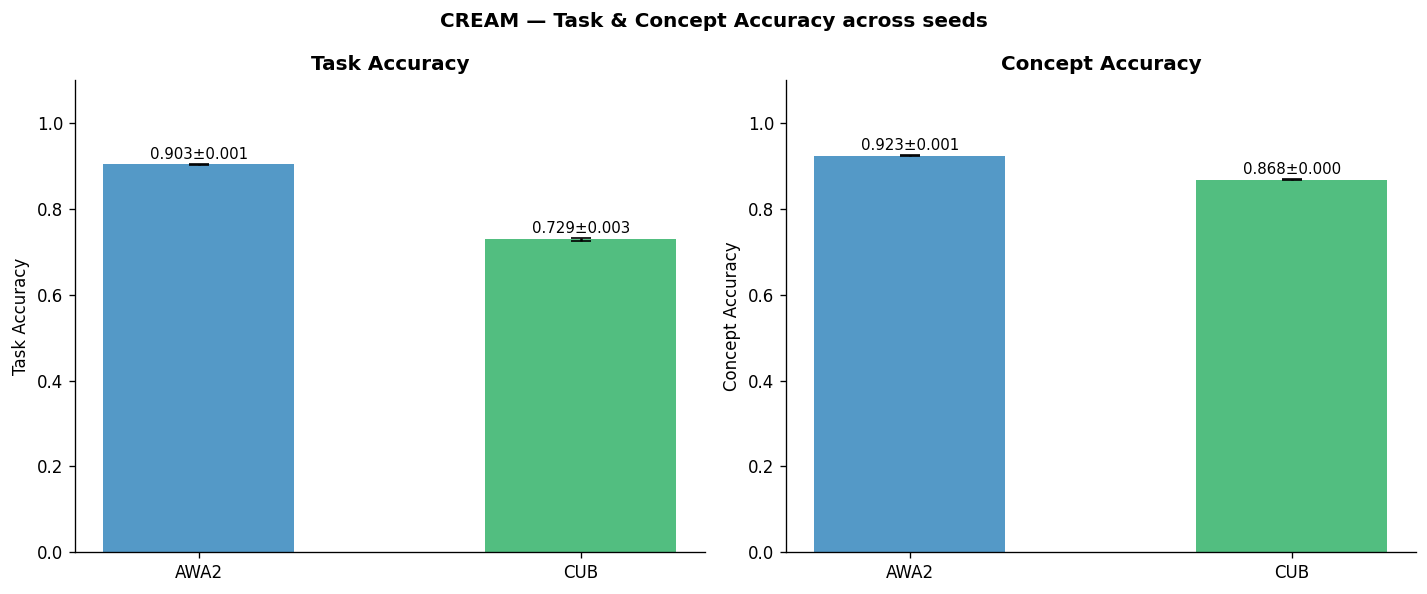

In [4]:
if not metrics_df.empty and 'test_task_accuracy' in metrics_df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle('CREAM — Task & Concept Accuracy across seeds', fontsize=12, fontweight='bold')

    for ax, metric, ylabel in [
        (axes[0], 'test_task_accuracy',    'Task Accuracy'),
        (axes[1], 'test_concept_accuracy', 'Concept Accuracy'),
    ]:
        if metric not in metrics_df.columns:
            ax.set_title(f'{ylabel} — not found'); continue

        datasets = [ds for ds in DATASETS if ds in metrics_df['dataset'].values]
        means = [metrics_df[metrics_df['dataset']==ds][metric].mean() for ds in datasets]
        stds  = [metrics_df[metrics_df['dataset']==ds][metric].std()  for ds in datasets]
        colors = [DATASETS[ds]['color'] for ds in datasets]

        bars = ax.bar(datasets, means, yerr=stds, capsize=6,
                      color=colors, alpha=0.8, width=0.5)
        for bar, m, s in zip(bars, means, stds):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + s + 0.005,
                    f'{m:.3f}±{s:.3f}', ha='center', va='bottom', fontsize=9)
        ax.set_title(ylabel, fontweight='bold')
        ax.set_ylabel(ylabel)
        ax.set_ylim(0, 1.1)

    plt.tight_layout()
    plt.show()

---
# Section 3 — Intervention Curves (mean ± std across seeds)

In [5]:
def load_interventions(dataset, seed):
    d = seed_dir(dataset, seed)
    csvs = list(d.rglob('intervention_results.csv'))
    if not csvs:
        return None
    df = pd.concat([pd.read_csv(f) for f in csvs], ignore_index=True)
    df['seed'] = seed
    df['dataset'] = dataset
    return df

all_iv = []
for ds in DATASETS:
    for s in DATASETS[ds]['seeds']:
        df = load_interventions(ds, s)
        if df is not None:
            all_iv.append(df)
        else:
            print(f'[MISSING] {ds} seed_{s} intervention_results.csv')

if all_iv:
    iv_df = pd.concat(all_iv, ignore_index=True)
    print('Columns:', list(iv_df.columns))
    display(iv_df.head())
else:
    iv_df = pd.DataFrame()
    print('No intervention results found yet.')

Columns: ['group_interventions', 'num_interventions', 'test_task_loss', 'test_task_accuracy', 'test_concept_loss', 'test_concept_accuracy', 'test_total_loss', 'test_task_loss_percent', 'seed', 'dataset']


,group_interventions,num_interventions,test_task_loss,test_task_accuracy,test_concept_loss,test_concept_accuracy,test_total_loss,test_task_loss_percent,seed,dataset
0,False,0.0,0.334897,0.902108,0.177500,0.923723,0.512396,64.254013,0,AWA2
1,False,1.0,0.331654,0.904252,0.175826,0.924473,0.507480,64.273758,0,AWA2
2,False,2.0,0.328273,0.903894,0.173631,0.925486,0.501903,64.349892,0,AWA2
3,False,3.0,0.326837,0.907467,0.171779,0.926350,0.498616,64.458275,0,AWA2
4,False,4.0,0.320574,0.907467,0.169894,0.927180,0.490468,64.300789,0,AWA2


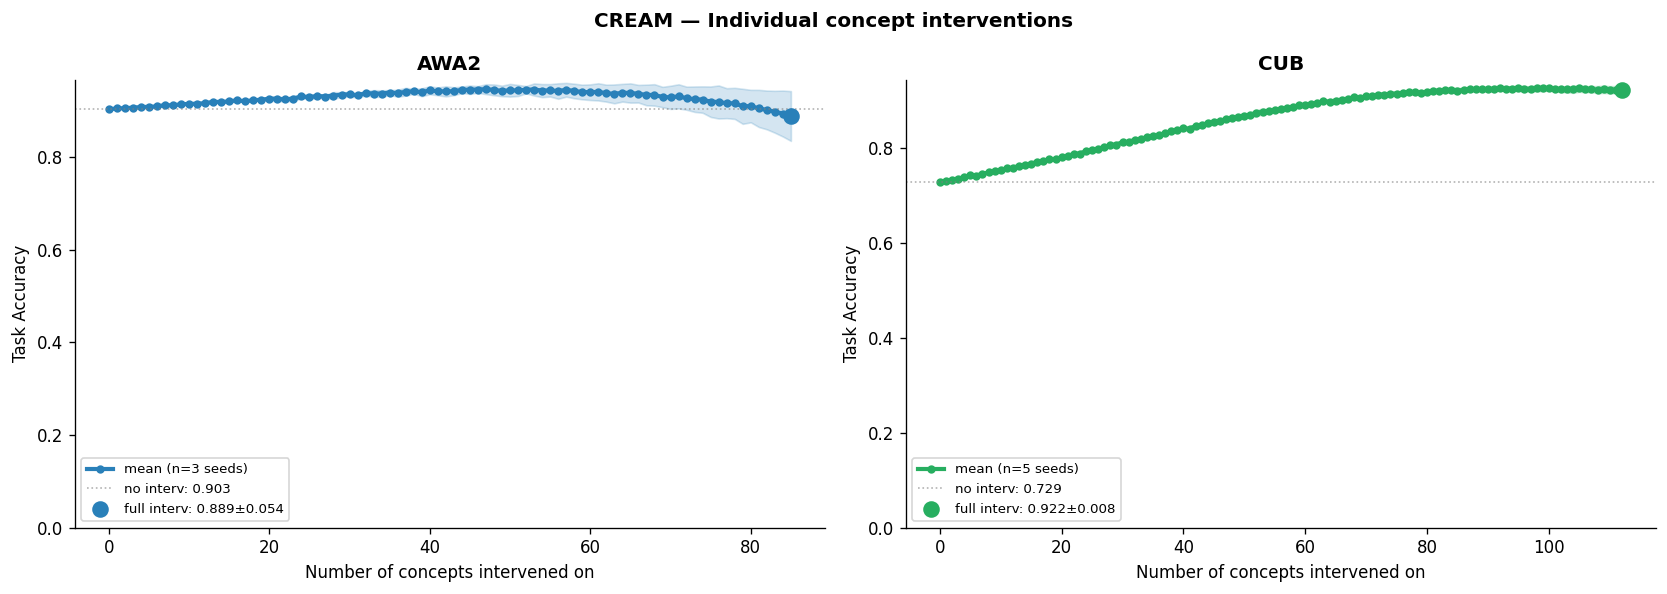

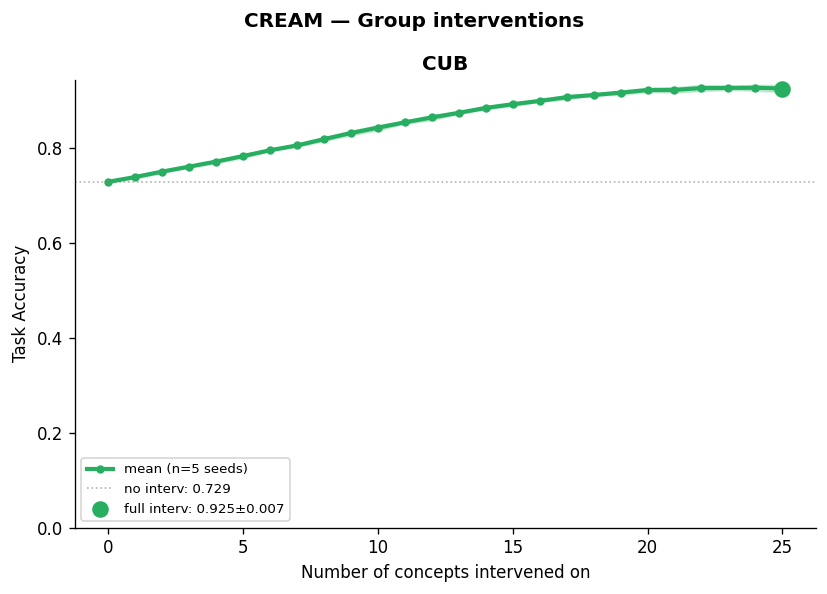

=== Intervention Summary ===


acc@0_mean  acc@0_std  acc@max_mean  acc@max_std
dataset mode                                                        
AWA2    individual      0.9033     0.0012        0.8887       0.0537
CUB     individual      0.7287     0.0028        0.9222       0.0078
        group           0.7287     0.0028        0.9251       0.0074

In [6]:
if not iv_df.empty and 'test_task_accuracy' in iv_df.columns:
    has_group = 'group_interventions' in iv_df.columns
    modes = [False, True] if has_group else [False]
    mode_labels = {False: 'Individual concept interventions', True: 'Group interventions'}

    for group_flag in modes:
        subset = iv_df[iv_df['group_interventions'] == group_flag] if has_group else iv_df
        if subset.empty:
            continue

        datasets_present = [ds for ds in DATASETS if ds in subset['dataset'].values]
        fig, axes = plt.subplots(1, len(datasets_present),
                                 figsize=(7 * len(datasets_present), 5),
                                 sharey=False)
        if len(datasets_present) == 1:
            axes = [axes]
        fig.suptitle(f'CREAM — {mode_labels[group_flag]}',
                     fontsize=12, fontweight='bold')

        for ax, ds in zip(axes, datasets_present):
            color = DATASETS[ds]['color']
            ds_data = subset[subset['dataset'] == ds]
            agg = (ds_data.groupby('num_interventions')['test_task_accuracy']
                   .agg(['mean', 'std', 'count']).reset_index())

            ax.plot(agg['num_interventions'], agg['mean'],
                    lw=2.5, marker='o', markersize=4, color=color,
                    label=f'mean (n={agg["count"].iloc[0]} seeds)')
            ax.fill_between(agg['num_interventions'],
                            agg['mean'] - agg['std'],
                            agg['mean'] + agg['std'],
                            alpha=0.2, color=color)

            # mark 0 and max
            acc0   = agg[agg['num_interventions']==0]['mean'].values
            acc_max = agg.iloc[-1]
            if len(acc0):
                ax.axhline(acc0[0], color='gray', lw=1, ls=':', alpha=0.6, label=f'no interv: {acc0[0]:.3f}')
            ax.scatter(acc_max['num_interventions'], acc_max['mean'],
                       color=color, s=80, zorder=5,
                       label=f'full interv: {acc_max["mean"]:.3f}±{acc_max["std"]:.3f}')

            ax.set_title(ds, fontweight='bold')
            ax.set_xlabel('Number of concepts intervened on')
            ax.set_ylabel('Task Accuracy')
            ax.set_ylim(bottom=0)
            ax.legend(fontsize=8)

        plt.tight_layout()
        plt.show()

    # Summary table
    print('=== Intervention Summary ===')
    rows = []
    for ds in DATASETS:
        for group_flag in ([False, True] if has_group else [False]):
            sub = iv_df[(iv_df['dataset']==ds)]
            if has_group:
                sub = sub[sub['group_interventions']==group_flag]
            if sub.empty: continue
            iv0   = sub[sub['num_interventions']==0]['test_task_accuracy']
            iv_max = sub[sub['num_interventions']==sub['num_interventions'].max()]['test_task_accuracy']
            rows.append({
                'dataset': ds,
                'mode': 'group' if group_flag else 'individual',
                'acc@0_mean': round(iv0.mean(), 4),
                'acc@0_std':  round(iv0.std(),  4),
                'acc@max_mean': round(iv_max.mean(), 4),
                'acc@max_std':  round(iv_max.std(),  4),
            })
    display(pd.DataFrame(rows).set_index(['dataset','mode']))
else:
    print('No intervention data loaded yet.')

---
# Section 4 — NEC / ANEC / ADI metrics

In [7]:
import json

def load_nec_adi(dataset, seed):
    d = seed_dir(dataset, seed) / 'last_metrics' / 'nec_anec_adi.json'
    if not d.exists():
        return None
    with open(d) as f:
        return json.load(f)

nec_rows, adi_rows, nec_curve_data = [], [], {}

for ds in DATASETS:
    nec_curve_data[ds] = {}
    for s in DATASETS[ds]['seeds']:
        r = load_nec_adi(ds, s)
        if r is None:
            print(f'[MISSING] {ds} seed_{s} nec_anec_adi.json')
            continue
        nec_rows.append({
            'dataset': ds, 'seed': s,
            'ANEC': r.get('ANEC'),
            **{k: v for k, v in r.get('NEC', {}).items()},
        })
        adi_rows.append({
            'dataset': ds, 'seed': s,
            'Sc_AD': r.get('Sc_AD'), 'Sc_AI': r.get('Sc_AI'), 'Sc_AG': r.get('Sc_AG'),
            'Sy_AD': r.get('Sy_AD'), 'Sy_AI': r.get('Sy_AI'), 'Sy_AG': r.get('Sy_AG'),
        })
        nec_curve_data[ds][s] = r.get('NEC', {})

if nec_rows:
    nec_df = pd.DataFrame(nec_rows)
    print('=== NEC / ANEC ===')
    display(nec_df.groupby('dataset').agg(['mean','std']).round(4))

if adi_rows:
    adi_df = pd.DataFrame(adi_rows)
    print('\n=== ADI (Sc=concept-level, Sy=class-level) ===')
    display(adi_df.groupby('dataset').agg(['mean','std']).round(4))

=== NEC / ANEC ===


seed            ANEC           NEC-5         NEC-10          NEC-15  \
        mean     std    mean     std    mean    std    mean     std    mean   
dataset                                                                       
AWA2     1.0  1.0000  0.7617  0.0511  0.5669  0.046  0.7511  0.0530  0.8034   
CUB      2.0  1.5811  0.7736  0.0092  0.4350  0.004  0.7551  0.0038  0.8394   

                 NEC-20          NEC-25          NEC-30          
            std    mean     std    mean     std    mean     std  
dataset                                                          
AWA2     0.0502  0.8046  0.0573  0.8169  0.0492  0.8274  0.0516  
CUB      0.0136  0.8662  0.0143  0.8707  0.0147  0.8748  0.0126


=== ADI (Sc=concept-level, Sy=class-level) ===


seed           Sc_AD           Sc_AI           Sc_AG           Sy_AD  \
        mean     std    mean     std    mean     std    mean     std    mean   
dataset                                                                        
AWA2     1.0  1.0000  0.0298  0.0045  0.4291  0.0321  0.0138  0.0008  0.1414   
CUB      2.0  1.5811  0.0284  0.0009  0.4438  0.0019  0.0161  0.0003  0.2264   

                  Sy_AI           Sy_AG          
            std    mean     std    mean     std  
dataset                                          
AWA2     0.0062  0.3087  0.0196  0.0157  0.0008  
CUB      0.0012  0.2941  0.0054  0.0294  0.0007

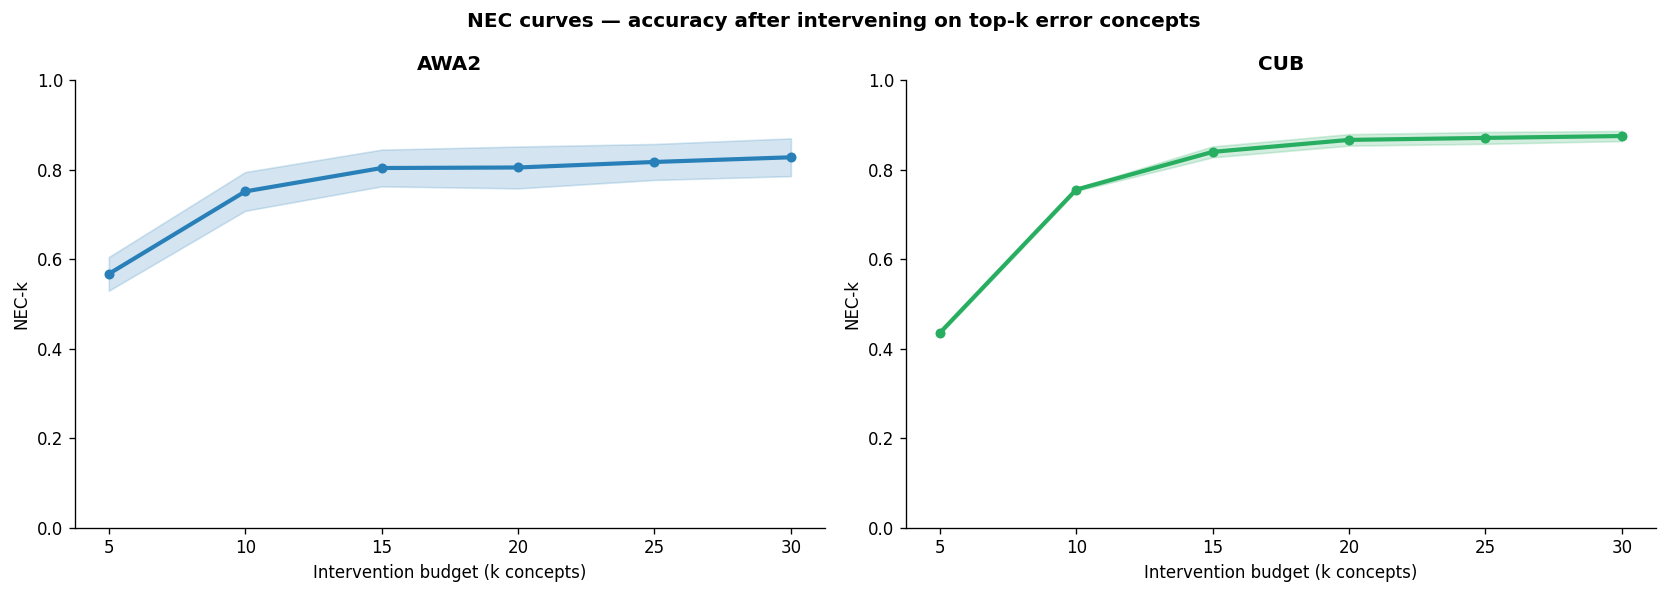

In [8]:
# NEC curve: accuracy at each budget, mean±std across seeds
if nec_curve_data:
    fig, axes = plt.subplots(1, len(DATASETS), figsize=(7*len(DATASETS), 5))
    if len(DATASETS) == 1: axes = [axes]
    fig.suptitle('NEC curves — accuracy after intervening on top-k error concepts',
                 fontsize=12, fontweight='bold')

    for ax, ds in zip(axes, DATASETS):
        color = DATASETS[ds]['color']
        seed_curves = nec_curve_data[ds]
        if not seed_curves: ax.set_title(f'{ds} — no data'); continue

        budgets = sorted(set(int(k.split('-')[1]) for s in seed_curves.values() for k in s))
        means, stds = [], []
        for b in budgets:
            vals = [seed_curves[s].get(f'NEC-{b}', np.nan) for s in seed_curves]
            vals = [v for v in vals if not np.isnan(v)]
            means.append(np.mean(vals) if vals else np.nan)
            stds.append(np.std(vals)  if vals else 0)

        ax.plot(budgets, means, lw=2.5, marker='o', markersize=5, color=color)
        ax.fill_between(budgets,
                        np.array(means) - np.array(stds),
                        np.array(means) + np.array(stds),
                        alpha=0.2, color=color)
        ax.set_title(ds, fontweight='bold')
        ax.set_xlabel('Intervention budget (k concepts)')
        ax.set_ylabel('NEC-k')
        ax.set_ylim(0, 1)

    plt.tight_layout()
    plt.show()

---
# Section 5 — Concept Saliency Maps (CAM)

In [9]:
import sys
sys.path.insert(0, '/home/dani00003/mCREAM')

import torch
import pandas as pd
from pathlib import Path
from src.models import Template_CBM_MultiClass
from src.utils import get_component_with_dicts, load_config
from src.cream_metrics import save_concept_saliency_maps

# ── Config — change dataset/seed here ─────────────────────────────────────
DATASET  = 'AWA2'   # or 'CUB'
SEED     = 0
N_IMAGES = 5        # how many test samples to visualize
DEVICE   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

CONFIG_PATHS = {
    'AWA2': f'/home/dani00003/mCREAM/all_configs/best_hparams/CREAM/CREAM_awa2_soft_seed{SEED}_config.yaml',
    'CUB':  f'/home/dani00003/mCREAM/all_configs/best_hparams/CREAM/CREAM_cub_soft_seed{SEED}_config.yaml',
}
config = load_config(CONFIG_PATHS[DATASET])

# ── Find checkpoint ────────────────────────────────────────────────────────
exp_name = config.get('experiment_name',
    Path(CONFIG_PATHS[DATASET]).stem.split('_')[0] + '_' +
    Path(CONFIG_PATHS[DATASET]).stem.split('_')[1])
exp_dir = (Path(config['paths']['default_root_dir'])
           / DATASET / 'train_cbm' / config['model_name'] / 'CREAM' / exp_name)
ckpts = sorted(exp_dir.rglob('*.ckpt'))
ckpt_path = next((c for c in ckpts if 'best' in c.name), ckpts[-1])
print('Checkpoint:', ckpt_path)

# ── Load model ─────────────────────────────────────────────────────────────
model = Template_CBM_MultiClass.load_from_checkpoint(str(ckpt_path),
                                                      map_location=DEVICE, strict=False)
model.eval().to(DEVICE)

# ── Load dataset ───────────────────────────────────────────────────────────
import pytorch_lightning as pl
pl.seed_everything(SEED)
dataset_class = get_component_with_dicts('dataset', DATASET)
datamodule = dataset_class(**config['dataset_params'])
datamodule.setup(stage='test')
loader = datamodule.test_dataloader()

# ── Load concept names from DAG ────────────────────────────────────────────
dag_df = pd.read_csv(config['paths']['DAG_file'], index_col=0)
concept_names = list(dag_df.index[:config['hyperparameters_model2']['num_concepts']])

# ── Generate and save saliency maps ───────────────────────────────────────
save_dir = str(exp_dir / 'saliency_maps')
save_concept_saliency_maps(
    model=model,
    dataloader=loader,
    device=DEVICE,
    concept_names=concept_names,
    save_dir=save_dir,
    n_images=N_IMAGES,
)
print(f'Maps saved to {save_dir}')

IndexError: list index out of range